# Fit a Match-up

In [58]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting
from ocpy.utils import coords as ocpy_coords
from ocpy.water import scattering

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals
from grab_pace_granules import load_from_json
import fitting as m_fitting

# Load up

In [6]:
match_file = 'matched_argo_bgc_profiles_bbp.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)

# Load up PACE granules
granules, pace = load_from_json('PACE_50clouds.json')


In [7]:
matched.head()

,cruise,filename,profile,lat,lon,time,solar_angle,pace_ids,closest_id,closest_file,closest_dist_km,closest_time
0,1902368,1902368QC.nc,13,56.348,-147.356,2024-07-09 04:35:00.000002048+00:00,13.134825,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI.20240708T202028.L2.OC_AOP.V3_0.nc,671.392674,2024-07-08 20:22:57.500000+00:00
1,1902369,1902369QC.nc,4,45.006,-133.357,2024-05-09 22:07:00.000001536+00:00,58.276589,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.620598,2024-05-10 20:36:38.500000+00:00
2,1902369,1902369QC.nc,5,45.020,-133.356,2024-05-10 09:02:59.999999488+00:00,-27.116450,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.579841,2024-05-10 20:36:38.500000+00:00
3,1902369,1902369QC.nc,6,45.020,-133.354,2024-05-10 19:52:59.999998464+00:00,60.421381,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.709744,2024-05-10 20:36:38.500000+00:00
4,1902369,1902369QC.nc,7,45.038,-133.348,2024-05-11 08:18:59.999995904+00:00,-26.535430,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,1.471472,2024-05-10 20:36:38.500000+00:00


# Try one

In [9]:
imt = 1
imatched = matched.iloc[imt]
imatched

cruise                                                       1902369
filename                                                1902369QC.nc
profile                                                            4
lat                                                           45.006
lon                                                         -133.357
time                             2024-05-09 22:07:00.000001536+00:00
solar_angle                                                58.276589
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...
closest_file              PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc
closest_dist_km                                             0.620598
closest_time                        2024-05-10 20:36:38.500000+00:00
Name: 1, dtype: object

In [10]:
gfile = os.path.join(os.getenv('OS_COLOR'), 'PACE', 'L2_AOP', 
                     imatched.closest_file)
assert os.path.isfile(gfile)

## Home grown

In [11]:
xds, flags = pace_io.load_oci_l2(gfile)

# Find closest

In [12]:
iRrs = 38
Rrs_ok = xds.Rrs_unc.values[:,:,iRrs] > 0.

In [17]:
coords = np.stack((xds.latitude.values.flatten(), 
    xds.longitude.values.flatten()), axis=1)
d = ocpy_coords.distance_from_latlon((
    imatched.lat, imatched.lon), coords)
# Unravel
imin = np.argmin(d)
dmin_ij = np.unravel_index(imin, xds.latitude.shape)

In [18]:
dmin_ij

(np.int64(519), np.int64(112))

In [21]:
xds.latitude.values[dmin_ij[0], dmin_ij[1]], xds.longitude.values[dmin_ij[0], dmin_ij[1]]

(np.float32(45.003075), np.float32(-133.35028))

In [22]:
imatched.lat, imatched.lon

(np.float64(45.006), np.float64(-133.357))

# Plot one

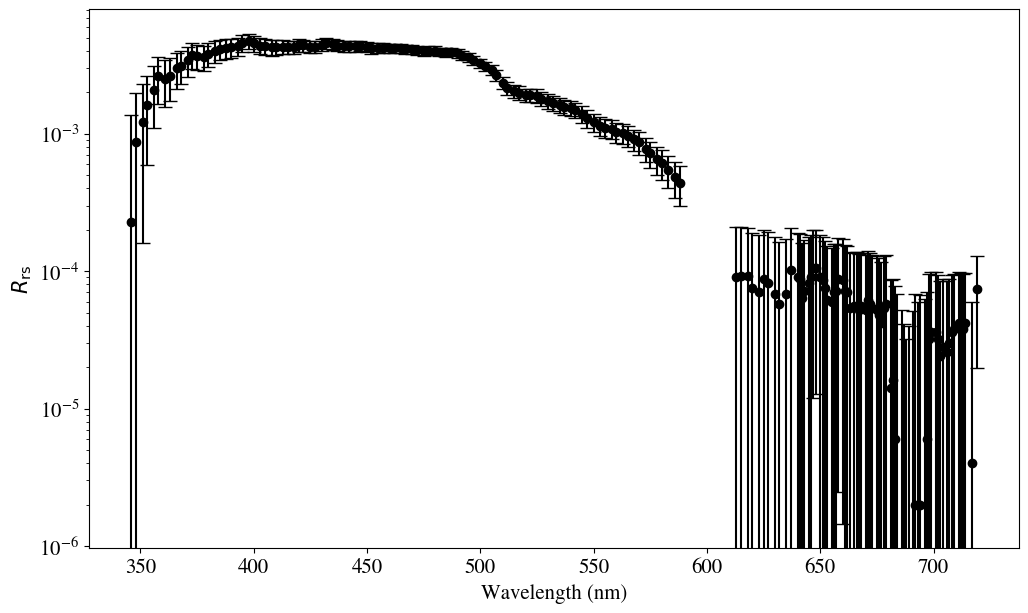

In [23]:
ix,iy = dmin_ij
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(xds.wavelength, xds.Rrs[ix,iy,:], yerr=xds.Rrs_unc[ix,iy,:],
                color='k',  fmt='o', capsize=5) 
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit one

## Parse out the data

In [24]:
ix, iy = dmin_ij
gd_wave = (xds.wavelength.data >= 400.) &  (xds.wavelength.data <= 700.) 
iwave = xds.wavelength.data[gd_wave]
ispec = xds.Rrs.data[ix,iy,gd_wave]
isig = xds.Rrs_unc.data[ix,iy,gd_wave]

## Fit with LM for first guess

In [31]:
#p.apriors
low_bounds, high_bounds = [], []
low_bounds += [item['pmin'] for item in p.apriors]
low_bounds += [item['pmin'] for item in p.bpriors]
high_bounds += [item['pmax'] for item in p.apriors]
high_bounds += [item['pmax'] for item in p.bpriors]
#
bounds = (np.array(low_bounds), np.array(high_bounds))
#
bounds

(array([-6.  ,  0.01, -6.  , -6.  ,  0.  ]),
 array([5.  , 0.02, 5.  , 5.  , 2.  ]))

In [32]:
p0 = [-1, 0.015, -1, -1, 1.5]
items = [(ispec, isig**2, p0, 0)]

In [33]:
ans, cov, idx = chisq_fit.fit(items[0], models, bounds=bounds)

In [34]:
ans

array([-1.35122738,  0.02      , -2.0978181 , -3.31226328,  2.        ])

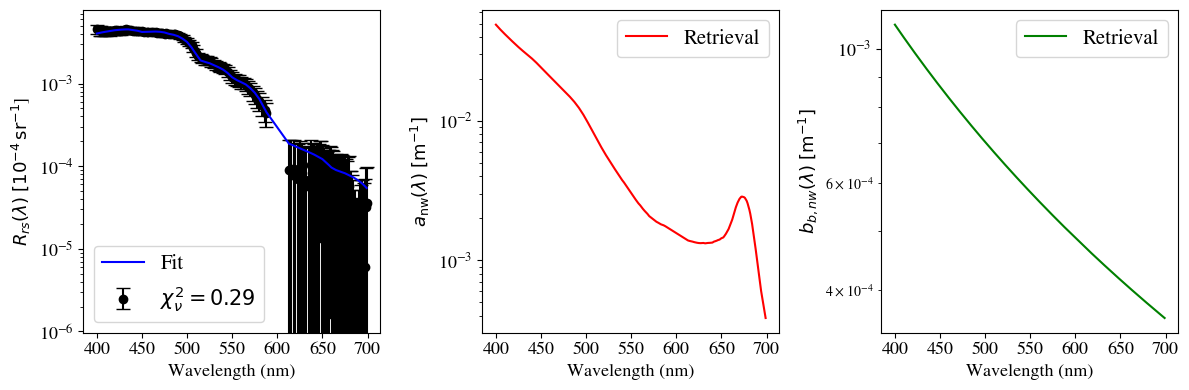

In [35]:
Chl = 10**ans[-1] / 0.05582
bing_plotting.show_fits(models, ans,  Chl, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                  log_abb=True,
                        
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

## Parameters

In [36]:
p = standard.expb_pow()
p

BING20_tuple(model_names=['ExpBricaud', 'Pow'], scl_noise='PACE', wv_min=400.0, wv_max=700.0, satellite='PACE', add_noise=False, apriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.01, 'pmax': 0.02}, {'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}], bpriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.0, 'pmax': 2.0}], set_Sdg=False, sSdg=0.002, beta=None, nMC=None, nsteps=40000, nburn=1000)

## Models

In [37]:
# Models
models = model_utils.init(p.model_names, iwave)

In [38]:
models

[<aNWModel: ExpBricaud, nparam=3>, <bbNWModel: Pow, nparam=2>]

## Priors

In [39]:
bing_priors.set_standard_priors(models, p)

## Initialize the MCMC

In [40]:
pdict = bing_inf.init_mcmc(models, nsteps=p.nsteps, nburn=p.nburn)

In [41]:
pdict['Chl'] = np.array([0.1 / 0.05582])
pdict['Y'] = None

## Items

In [42]:
#p0 = [-1, 0.015, -1, -1, 1.5]
p0 = ans.tolist()
items = [(ispec, isig**2, p0, 0)]

## Fit me

## Check me

In [43]:
chains, idx = bing_inf.fit_one(
        items[0], models=models, pdict=pdict, chains_only=True)

idx=0
Running burn-in


  0%|                                                          | 0/1000 [00:00<?, ?it/s]/home/xavier/miniconda3/envs/ocean/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1203.45it/s]


Running full model


100%|████████████████████████████████████████████| 40000/40000 [00:44<00:00, 890.69it/s]


In [56]:
chains.shape

(40000, 16, 5)

In [57]:
ulist = evaluate.reconstruct_from_chains(models, chains)#, perc=perc)

In [73]:
stats = evaluate.calc_stats(chains)
stats

{'names': ['p0', 'p1', 'p2', 'p3', 'p4'],
 'med': array([-1.3429543 ,  0.01857862, -2.228447  , -3.2999163 ,  1.8692293 ],
       dtype=float32),
 'p05': array([-1.3941916 ,  0.01529577, -3.8884423 , -3.351069  ,  1.4842802 ],
       dtype=float32),
 'p95': array([-1.2878271 ,  0.01987754, -2.045908  , -3.251106  ,  1.9907156 ],
       dtype=float32)}

Saved: tmp.png


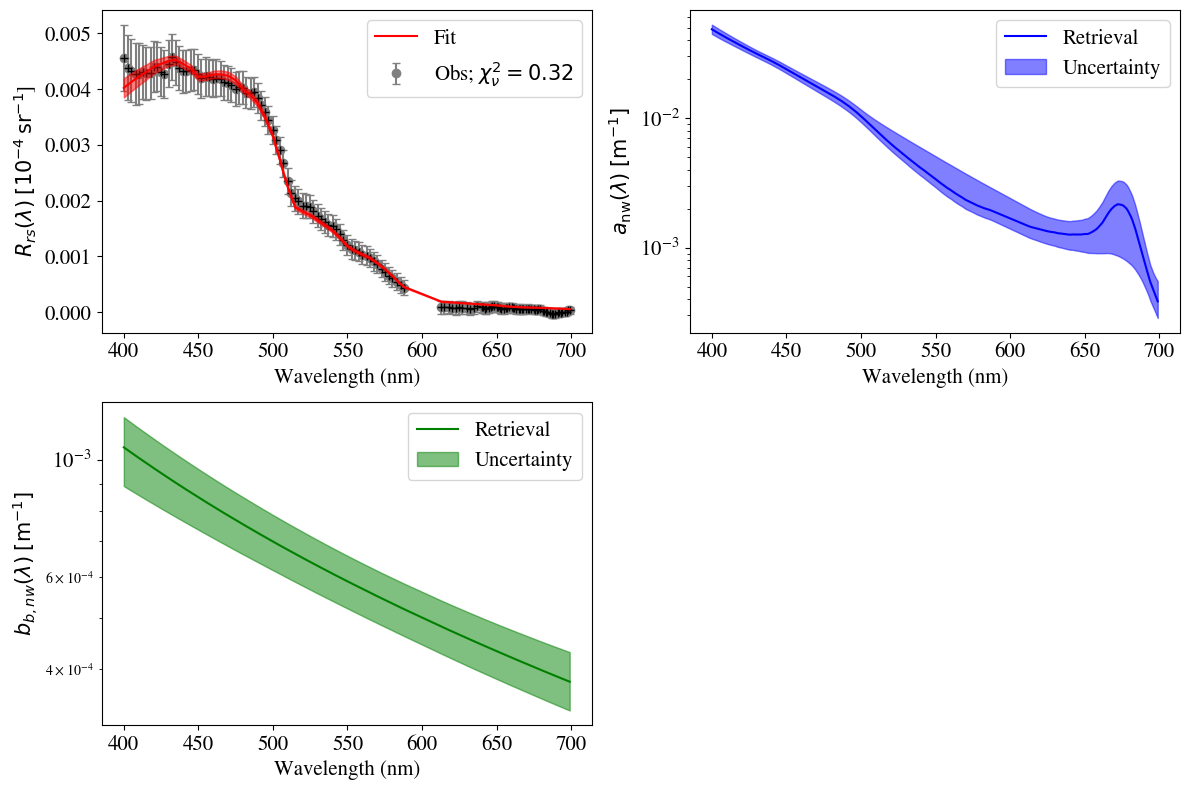

In [72]:
reload(m_fitting)
Rrs_obs=dict(wave=models[0].wave, spec=ispec, var=isig**2)
m_fitting.plot_fit(models, chains, Rrs_obs, stats=stats, show_Rsig=True,
                   ulist=ulist, outfile='tmp.png')
plt.show()

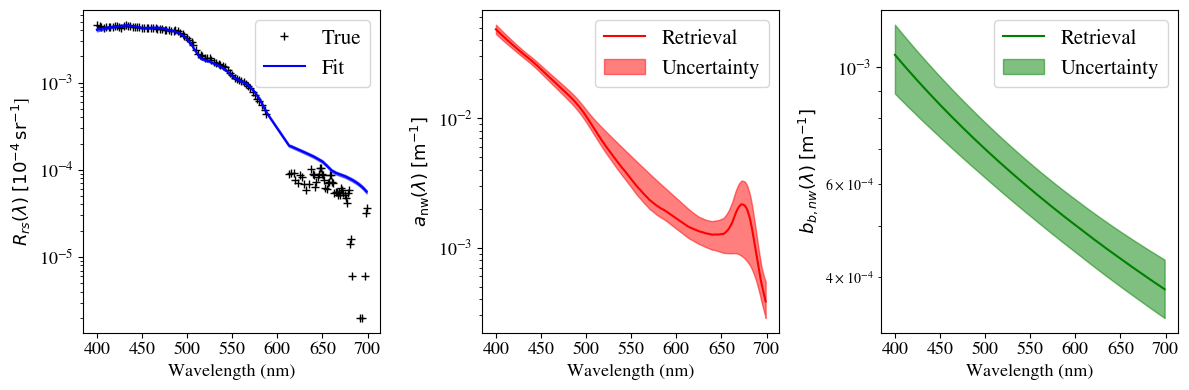

In [56]:
reload(bing_plotting)
reload(scattering)
bing_plotting.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec),#, var=isig**2),
                        log_abb=True,
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

## Corner plot

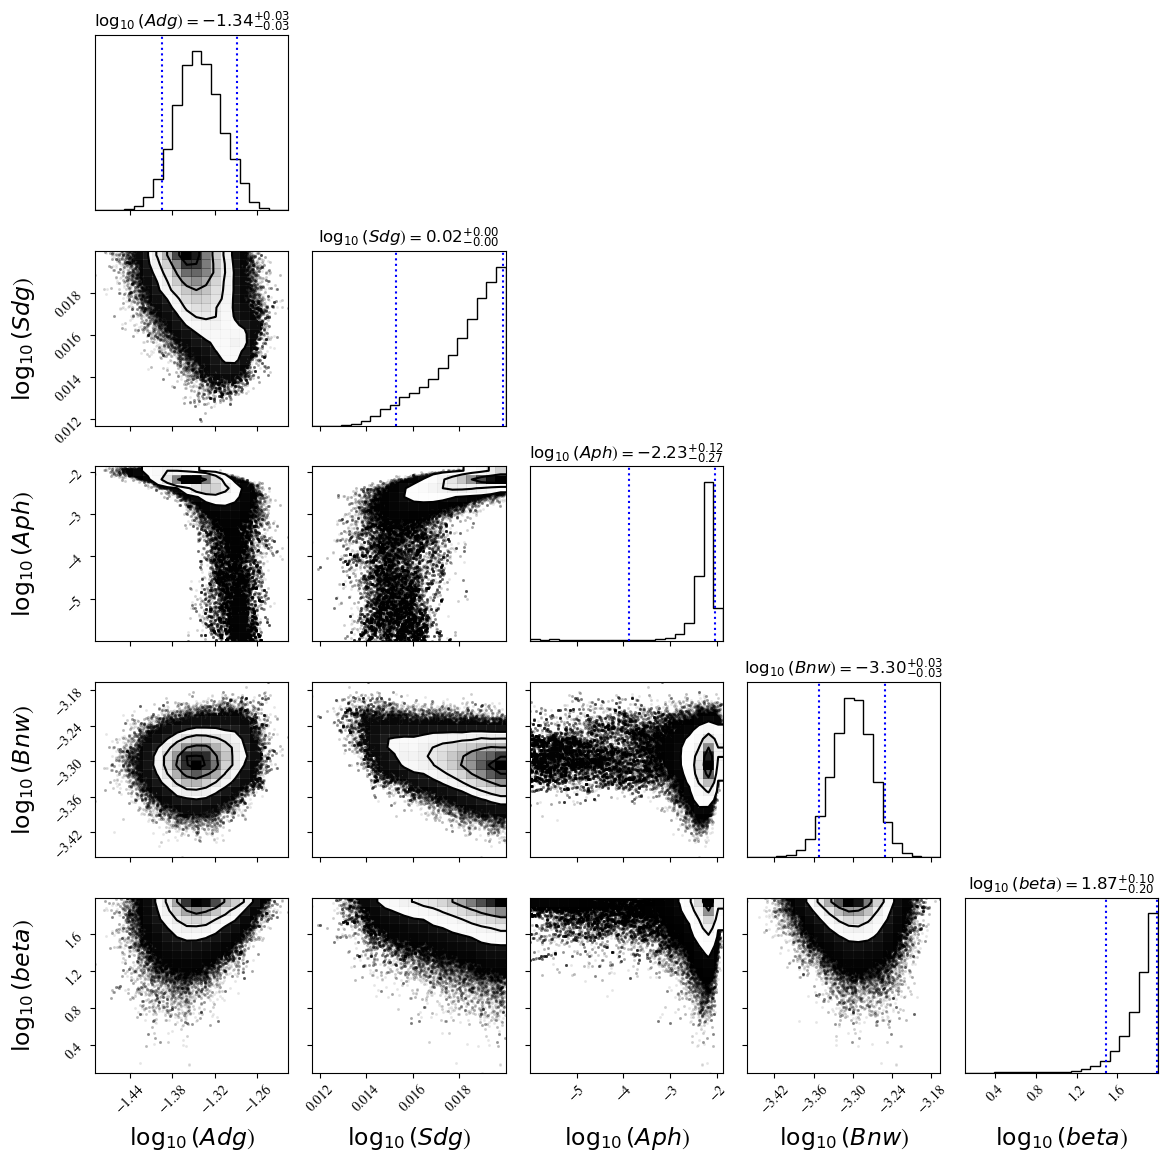

In [53]:
reload(bing_plotting)
_= bing_plotting.corner_plot(chains, models=models)

In [63]:
ans


array([-1.89600591,  0.01829992, -2.23742088, -3.01622879,  2.        ])